In [11]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical


In [3]:
airline = pd.read_csv("airline.tsv", sep="\t", encoding="latin1")
eco = pd.read_csv("eco_news.tsv", sep="\t", encoding="latin1")
glo = pd.read_csv("glo_warm.tsv", sep="\t", encoding="latin1")
emo = pd.read_csv("text_emo.tsv", sep="\t", encoding="latin1")

In [4]:
def map_labels(label):
    label = str(label).lower().strip()

    # Airline dataset
    if label == "positive":
        return "joy"
    if label == "negative":
        return "anger"
    if label == "neutral":
        return "neutral"

    # Eco news stance dataset
    if label == "yes":
        return "support"
    if label == "no":
        return "oppose"

    # Text emotion dataset
    if label in ["sadness"]:
        return "sadness"
    if label in ["enthusiasm", "happiness", "joy"]:
        return "joy"
    if label in ["anger", "hate"]:
        return "anger"

    # Anything else
    return "other"

datasets = [airline, eco, glo, emo]
for i in range(len(datasets)):
    datasets[i]["label"] = datasets[i]["label"].apply(map_labels)

df = pd.concat(datasets, ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)  # shuffle
df.head()

,text,label
0,Author: Tara Loader Wilkinson</br></br>Didier ...,oppose
1,@sanchaaaa im sadd sancha june 18 for me is a...,other
2,Heyya guys! does anyone know how to give formu...,other
3,@Katarinea Oh wow ouch...,other
4,Happy Mother's Day ~ and for single dads who p...,neutral


In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\@\w+|\#","", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.strip()
    return text

df["text"] = df["text"].astype(str).apply(clean_text)
df.head()

,text,label
0,author tara loader wilkinsonbrbrdidier duret c...,oppose
1,im sadd sancha june for me is a fail its go...,other
2,heyya guys does anyone know how to give formul...,other
3,oh wow ouch,other
4,happy mothers day and for single dads who pla...,neutral


In [6]:
X = df["text"].values
y = df["label"].astype("category").cat.codes.values

num_classes = len(np.unique(y))
print("Classes:", df["label"].astype("category").cat.categories.tolist())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Classes: ['anger', 'joy', 'neutral', 'oppose', 'other', 'sadness', 'support']


In [7]:
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=40)
X_test = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=40)

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

In [8]:
label_categories = df["label"].astype("category").cat.categories.tolist()
print("Label classes (index -> label):")
for i, lbl in enumerate(label_categories):
    print(i, lbl)


Label classes (index -> label):
0 anger
1 joy
2 neutral
3 oppose
4 other
5 sadness
6 support


In [16]:
embedding_dim = 200
glove_path = f"glove.6B/glove.6B.{embedding_dim}d.txt"

emb_index = {}
with open(glove_path, encoding="utf8") as f:
    for line in f:
        parts = line.rstrip().split(" ")
        word = parts[0]
        coefs = np.asarray(parts[1:], dtype="float32")
        emb_index[word] = coefs

print("Loaded GloVe vectors:", len(emb_index))

word_index = tokenizer.word_index
num_words = min(20000, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))
found = 0
for word, i in word_index.items():
    if i >= num_words: continue
    vec = emb_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec
        found += 1
print(f"Found {found} word vectors out of {num_words}")

Loaded GloVe vectors: 400000
Found 18098 word vectors out of 20000


In [17]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ----- Ensure y_train and y_test are integer labels -----
if y_train.ndim == 2:
    y_train_int = np.argmax(y_train, axis=1)
else:
    y_train_int = y_train.copy()

if y_test.ndim == 2:
    y_test_int = np.argmax(y_test, axis=1)
else:
    y_test_int = y_test.copy()

# ----- Compute class weights from TRAIN ONLY -----
classes = np.unique(y_train_int)
class_weights_array = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
class_weights = dict(zip(classes, class_weights_array))
print("Class Weights:", class_weights)

# ----- Convert to one-hot labels AFTER computing class weights -----
num_classes = len(classes)
y_train_cat = to_categorical(y_train_int, num_classes)
y_test_cat  = to_categorical(y_test_int, num_classes)

# ----- Build the Model -----
vocab_size = embedding_matrix.shape[0]       # IMPORTANT
embedding_dim = embedding_matrix.shape[1]    # should be 50, 100, 200, or 300
maxlen = X_train.shape[1]                    # ensure correct maxlen

model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=maxlen,
              trainable=True),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ----- Train Model -----
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train_cat,
    validation_split=0.15,
    epochs=20,
    batch_size=64,
    class_weight=class_weights,   # <--- APPLIED HERE
    callbacks=[es],
    verbose=1
)


Class Weights: {np.int64(0): np.float64(0.8997661940085112), np.int64(1): np.float64(1.1468879312193134), np.int64(2): np.float64(0.8137274289973683), np.int64(3): np.float64(1.4434669976793135), np.int64(4): np.float64(0.4255799891799001), np.int64(5): np.float64(1.8561365765640723), np.int64(6): np.float64(4.842657975737824)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     4,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,000,000 (15.26 MB)

 Trainable params: 4,000,000 (15.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.2622 - loss: 1.5618 - val_accuracy: 0.4235 - val_loss: 1.2745
Epoch 2/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4197 - loss: 1.1623 - val_accuracy: 0.4746 - val_loss: 1.1774
Epoch 3/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4648 - loss: 1.0743 - val_accuracy: 0.4717 - val_loss: 1.1546
Epoch 4/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4880 - loss: 1.0207 - val_accuracy: 0.4978 - val_loss: 1.1010
Epoch 5/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5047 - loss: 0.9742 - val_accuracy: 0.4880 - val_loss: 1.1080
Epoch 6/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5106 - loss: 0.9488 - val_accuracy: 0.5015 - val_loss: 1.0816
Epoch 7/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5296 - loss: 0.9161 - val_accuracy: 0.5101 - val_loss: 1.0630
Epoch 8/20
711/711 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.5394 - loss: 0.8868 - va

In [21]:
import re
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_emotion(text):
    # same cleaning as training
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+|\#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.strip()

    seq = tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=maxlen)

    pred = model.predict(seq)[0]
    idx = np.argmax(pred)
    return label_categories[idx], float(pred[idx])
sentence = "I was using the product, it has a critical issue while using it for the first time, thought it was the defect of the product, but turned out its my defect, but the product is very good."
emotion, confidence = predict_emotion(sentence)
print("Prediction:", emotion, "| Confidence:", round(confidence, 3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Prediction: oppose | Confidence: 0.871


418/418 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step

Classification Report:

              precision    recall  f1-score   support

       anger       0.80      0.70      0.75      2118
         joy       0.37      0.59      0.45      1668
     neutral       0.44      0.48      0.46      2346
      oppose       0.86      0.78      0.82      1338
       other       0.75      0.25      0.38      4456
     sadness       0.23      0.65      0.34      1048
     support       0.43      0.56      0.49       399

    accuracy                           0.50     13373
   macro avg       0.55      0.57      0.52     13373
weighted avg       0.61      0.50      0.50     13373



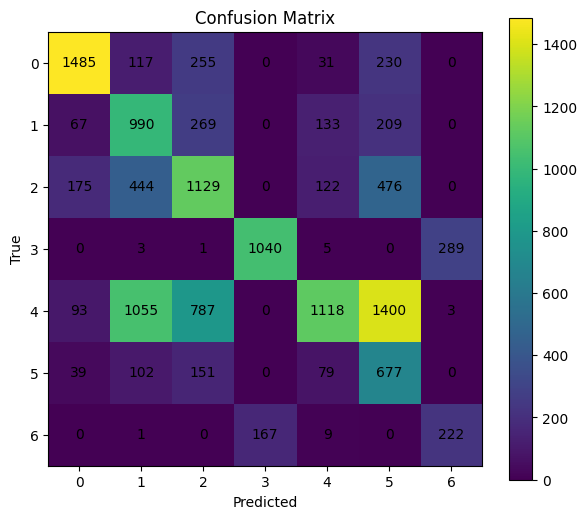

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Predict on test set
y_pred_probs = model.predict(X_test)
y_pred_int = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test_int, y_pred_int, target_names=label_categories))

# Confusion Matrix
cm = confusion_matrix(y_test_int, y_pred_int)

plt.figure(figsize=(7,6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Add numbers to cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


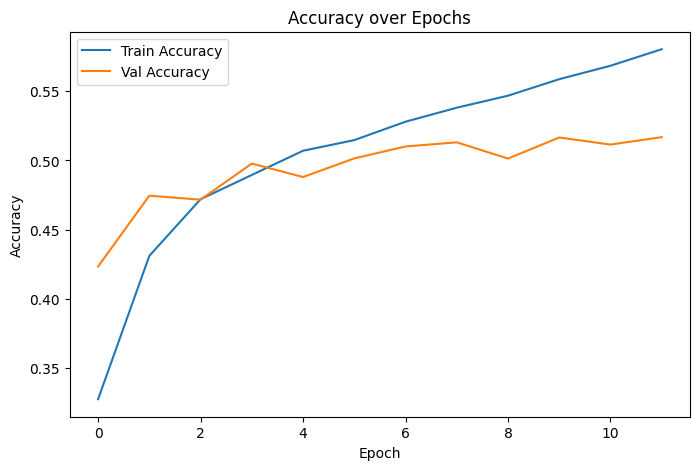

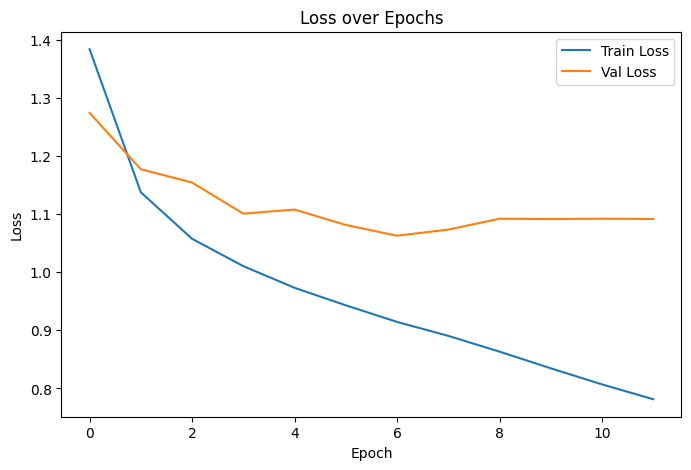

In [20]:
# Plot training & validation accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy over Epochs")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# Plot training & validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over Epochs")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()
